
=== TABELA COMPARATIVA ===
Método Numérico  Raiz Encontrada (UA)  Iterações  Erro Final f(x)  Distância Real (km)
      Bissecção          0.0100370026         16    -0.0000000000 1,501,514.2117065354
  Falsa Posição          0.0100369167         22    -0.0000000001 1,501,501.3730439155
     Ponto Fixo          0.0100370231          4    -0.0000000000 1,501,517.2899388808
 Newton-Raphson          0.0100370231          3     0.0000000000 1,501,517.2899502330
        Secante          0.0100370231          5    -0.0000000000 1,501,517.2899502327


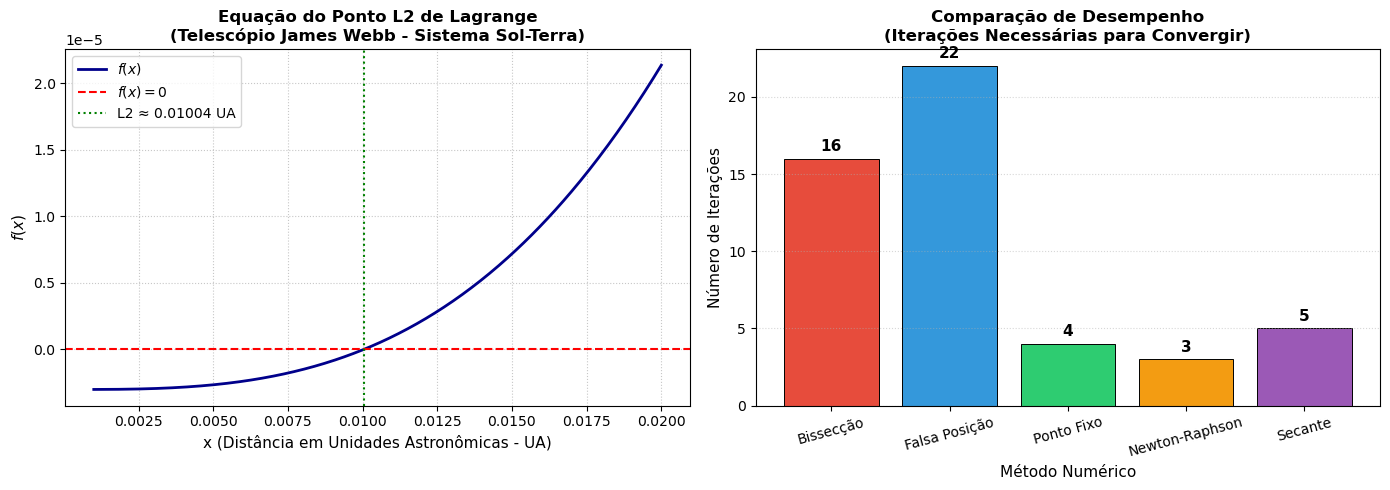


Gráficos salvos em graficos_l2.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# constantes do problema
# µ = razão de massa Terra/Sol (parâmetro de massa reduzida)
# µ = M_Terra / (M_Sol + M_Terra) ≈ M_Terra / M_Sol (pois M_Terra << M_Sol)

mu = 3.0034e-6          # adimensional
tolerancia = 1e-10
max_iter = 100
au_to_km = 149_597_870.7  # 1 UA em km

# ==============================================================================
# EQUAÇÃO DE EQUILÍBRIO PARA L2
#
# A condição de equilíbrio no ponto L2, em coordenadas rotativas normalizadas,
# resulta na equação polinomial de grau 5 (obtida expandindo e zerando a
# equação de força centrífuga + gravitacional):
#
#   f(x) = x^5 + (3-µ)x^4 + (3-2µ)x^3 - µx^2 - 2µx - µ = 0
#
# Para µ << 1 (caso Sol-Terra), (3-µ) ≈ 3 e (3-2µ) ≈ 3, dando:
#   f(x) ≈ x^5 + 3x^4 + 3x^3 - µx^2 - 2µx - µ = 0
#
# onde x é a distância de L2 à Terra em unidades astronômicas (UA),
# medida a partir do centro de massa do sistema (aproximadamente o Sol).
# ==============================================================================

def f(x):
    """Polinômio de grau 5 cuja raiz positiva pequena é a posição de L2."""
    return x**5 + 3*x**4 + 3*x**3 - mu*x**2 - 2*mu*x - mu

def df(x):
    """Derivada analítica de f(x) — usada no método de Newton-Raphson."""
    return 5*x**4 + 12*x**3 + 9*x**2 - 2*mu*x - 2*mu

def g(x):
    """
    Função de iteração para o método do Ponto Fixo.
    Isolamos x^3 da equação: x^3 = (µ + 2µx + µx^2 - x^5 - 3x^4) / 3
    Tomamos a raiz cúbica com sinal preservado para garantir convergência.
    """
    numerator = mu + 2*mu*x + mu*x**2 - x**5 - 3*x**4
    # CORREÇÃO: dividir por 3 (coeficiente de x^3), não apenas por 3.0 genérico
    term = numerator / 3.0
    return np.sign(term) * np.abs(term)**(1.0/3.0)

# métodos numéricos

def bisseccao(a, b, tol, max_iterations):
    """Bissecção: divide o intervalo [a,b] ao meio a cada iteração."""
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")
    for i in range(max_iterations):
        c = (a + b) / 2.0
        if abs(f(c)) < tol or (b - a) / 2.0 < tol:
            return c, i + 1
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return c, max_iterations

def falsa_posicao(a, b, tol, max_iterations):
    """Falsa Posição (Regula Falsi): usa interpolação linear entre a e b."""
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")
    for i in range(max_iterations):
        # ponto de cruzamento pela reta secante entre (a, f(a)) e (b, f(b))
        c = (a * f(b) - b * f(a)) / (f(b) - f(a))
        if abs(f(c)) < tol:
            return c, i + 1
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return c, max_iterations

def ponto_fixo(x0, tol, max_iterations):
    """Ponto Fixo: itera x_{n+1} = g(x_n) até convergência."""
    x = x0
    for i in range(max_iterations):
        x_next = g(x)
        if abs(x_next - x) < tol:
            return x_next, i + 1
        x = x_next
    return x, max_iterations

def newton_raphson(x0, tol, max_iterations):
    """Newton-Raphson: usa derivada para convergência quadrática."""
    x = x0
    for i in range(max_iterations):
        deriv = df(x)
        if deriv == 0:
            raise ZeroDivisionError("Derivada nula — escolha outro x0.")
        x_next = x - f(x) / deriv
        if abs(x_next - x) < tol:
            return x_next, i + 1
        x = x_next
    return x, max_iterations

def secante(x0, x1, tol, max_iterations):
    """Secante: aproxima a derivada por diferença finita (não precisa de df)."""
    for i in range(max_iterations):
        denom = f(x1) - f(x0)
        if denom == 0:
            raise ZeroDivisionError("Divisão por zero no método da Secante.")
        x_next = x1 - f(x1) * (x1 - x0) / denom
        if abs(x_next - x1) < tol:
            return x_next, i + 1
        x0, x1 = x1, x_next
    return x1, max_iterations

# execução
# chutes iniciais definidos com base na análise gráfica de f(x):
# a raiz está próxima de x ≈ 0.01 UA (≈ 1,5 milhões de km atrás da Terra)

a, b = 0.001, 0.02
x0   = 0.01
x1   = 0.015

resultados = []

r_bi, i_bi = bisseccao(a, b, tolerancia, max_iter)
resultados.append(["Bissecção",       r_bi, i_bi, f(r_bi), r_bi * au_to_km])

r_fp, i_fp = falsa_posicao(a, b, tolerancia, max_iter)
resultados.append(["Falsa Posição",   r_fp, i_fp, f(r_fp), r_fp * au_to_km])

r_pf, i_pf = ponto_fixo(x0, tolerancia, max_iter)
resultados.append(["Ponto Fixo",      r_pf, i_pf, f(r_pf), r_pf * au_to_km])

r_nr, i_nr = newton_raphson(x0, tolerancia, max_iter)
resultados.append(["Newton-Raphson",  r_nr, i_nr, f(r_nr), r_nr * au_to_km])

r_sc, i_sc = secante(x0, x1, tolerancia, max_iter)
resultados.append(["Secante",         r_sc, i_sc, f(r_sc), r_sc * au_to_km])

# Tabela comparativa
pd.options.display.float_format = '{:,.10f}'.format
df_results = pd.DataFrame(resultados, columns=[
    "Método Numérico", "Raiz Encontrada (UA)", "Iterações",
    "Erro Final f(x)", "Distância Real (km)"
])
print("\n=== TABELA COMPARATIVA ===")
print(df_results.to_string(index=False))

# gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Curva f(x) com a raiz ---
x_vals = np.linspace(0.001, 0.02, 500)
y_vals = f(x_vals)

axes[0].plot(x_vals, y_vals, color='darkblue', linewidth=2, label='$f(x)$')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='$f(x) = 0$')
axes[0].axvline(r_nr, color='green', linestyle=':', linewidth=1.5,
                label=f'L2 ≈ {r_nr:.5f} UA')
axes[0].set_title('Equação do Ponto L2 de Lagrange\n(Telescópio James Webb - Sistema Sol-Terra)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('x (Distância em Unidades Astronômicas - UA)', fontsize=11)
axes[0].set_ylabel('$f(x)$', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.7)

# gráfico 2: comparação de iterações
metodos  = [r[0] for r in resultados]
iters    = [r[2] for r in resultados]
cores    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

bars = axes[1].bar(metodos, iters, color=cores, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, iters):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[1].set_title('Comparação de Desempenho\n(Iterações Necessárias para Convergir)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Método Numérico', fontsize=11)
axes[1].set_ylabel('Número de Iterações', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('graficos_l2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGráficos salvos em graficos_l2.png")